# TensorFlow Basics and Linear Classification Example

In [ ]:
import tensorflow as tf

x = tf.ones(shape =(2,1))
print(x)

tf.Tensor(
[[1.]
 [1.]], shape=(2, 1), dtype=float32)


In [ ]:
x = tf.zeros(shape =(2,1))
print(x)

tf.Tensor(
[[0.]
 [0.]], shape=(2, 1), dtype=float32)


In [ ]:
x = tf.random.normal(shape =(3,1), mean =0. , stddev= 1.)
print(x)

tf.Tensor(
[[-0.29692426]
 [-0.32033998]
 [-1.271267  ]], shape=(3, 1), dtype=float32)


In [ ]:
import numpy as np

x = np.ones(shape =(2,2))
x[0,0] = 0.
print(x)

[[0. 1.]
 [1. 1.]]


In [ ]:
x = tf.ones(shape = (2,2))
x[0,0] = 0

TypeError: 'tensorflow.python.framework.ops.EagerTensor' object does not support item assignment

In [ ]:
v = tf.Variable(initial_value=tf.random.normal(shape=(3,1)))

In [ ]:
print(v)

<tf.Variable 'Variable:0' shape=(3, 1) dtype=float32, numpy=
array([[ 0.08226828],
       [-1.4098055 ],
       [-0.8748828 ]], dtype=float32)>


In [ ]:
v.assign(tf.ones((3,1)))

<tf.Variable 'UnreadVariable' shape=(3, 1) dtype=float32, numpy=
array([[1.],
       [1.],
       [1.]], dtype=float32)>

In [ ]:
v[0,0].assign(5.)

<tf.Variable 'UnreadVariable' shape=(3, 1) dtype=float32, numpy=
array([[5.],
       [1.],
       [1.]], dtype=float32)>

In [ ]:
v.assign_add(tf.ones((3,1)))

<tf.Variable 'UnreadVariable' shape=(3, 1) dtype=float32, numpy=
array([[6.],
       [7.],
       [2.]], dtype=float32)>

In [ ]:
a = tf.ones((2,2))
b = tf.square(a)
c = tf.sqrt(a)
d = b + c
e = tf.matmul(a,b)


In [ ]:
print("a: ", a,"\n" ,"b: ",b, "\n", "c: ", c, "\n", "d: " , d, "\n", "e: ", e)

a:  tf.Tensor(
[[1. 1.]
 [1. 1.]], shape=(2, 2), dtype=float32) 
 b:  tf.Tensor(
[[1. 1.]
 [1. 1.]], shape=(2, 2), dtype=float32) 
 c:  tf.Tensor(
[[1. 1.]
 [1. 1.]], shape=(2, 2), dtype=float32) 
 d:  tf.Tensor(
[[2. 2.]
 [2. 2.]], shape=(2, 2), dtype=float32) 
 e:  tf.Tensor(
[[2. 2.]
 [2. 2.]], shape=(2, 2), dtype=float32)


In [ ]:
e *= d
print(e)

tf.Tensor(
[[4. 4.]
 [4. 4.]], shape=(2, 2), dtype=float32)


In [ ]:
input_var = tf.Variable(initial_value= 3.)
with tf.GradientTape() as tape:
  result = tf.square(input_var)
gradient = tape.gradient(result, input_var)

In [ ]:
print(gradient)

tf.Tensor(6.0, shape=(), dtype=float32)


In [ ]:
print(input_var,"\n" ,result,"\n" ,gradient)

<tf.Variable 'Variable:0' shape=() dtype=float32, numpy=3.0> 
 tf.Tensor(9.0, shape=(), dtype=float32) 
 tf.Tensor(6.0, shape=(), dtype=float32)


In [ ]:
input_const = tf.constant(3.)
with tf.GradientTape() as tape:
  tape.watch(input_const)
  result = tf.square(input_const)
gradient = tape.gradient(result, input_const)


print(input_const,"\n" ,result,"\n" ,gradient)

tf.Tensor(3.0, shape=(), dtype=float32) 
 tf.Tensor(9.0, shape=(), dtype=float32) 
 tf.Tensor(6.0, shape=(), dtype=float32)


In [ ]:
time = tf.Variable(3.)
with tf.GradientTape() as outer_tape:
  with tf.GradientTape() as inner_tape:
    position = 4.9 * time ** 2
  speed = inner_tape.gradient(position, time)
acceleration = outer_tape.gradient(speed,time)

In [ ]:
print("time: ",time,"\n" ,"Speed: ",speed,"\n" ,"acceleration: ", acceleration)

time:  <tf.Variable 'Variable:0' shape=() dtype=float32, numpy=3.0> 
 Speed:  tf.Tensor(29.400002, shape=(), dtype=float32) 
 acceleration:  tf.Tensor(9.8, shape=(), dtype=float32)


#                End to End Linear Classification Model


In [ ]:
num_samples_per_class = 1000
negative_samples = np.random.multivariate_normal(
    mean = [0,3],
    cov =[[1,0.5], [0.5,1]],
    size = num_samples_per_class)
positive_samples = np.random.multivariate_normal(
    mean = [3,0],
    cov =[[1,0.5], [0.5,1]],
    size = num_samples_per_class)

inputs = np.vstack((negative_samples, positive_samples)).astype(np.float32)

In [ ]:
inputs.shape

(2000, 2)

In [ ]:
targets = np.vstack((np.zeros((num_samples_per_class,1),dtype="float32"),
                     np.ones((num_samples_per_class,1),dtype="float32")))

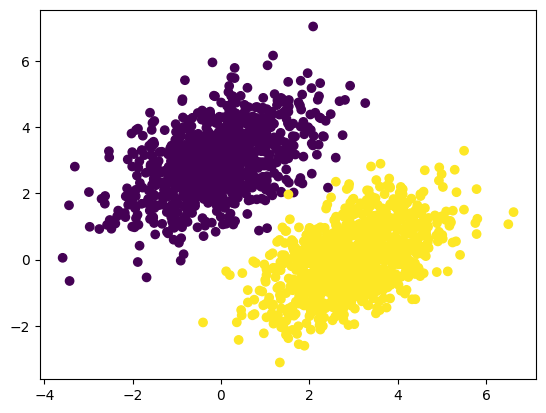

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(inputs[:,0], inputs[:,1], c=targets[:,0])
plt.show()

In [ ]:
#creating a linear classifier
input_dim = 2
output_dim = 1
W = tf.Variable(initial_value=tf.random.uniform(shape=(input_dim, output_dim)))
b = tf.Variable(initial_value=tf.zeros(shape=(output_dim, )))


#Define forward pass
def model(inputs):
  return tf.matmul(inputs, W) + b


#The mean squared error loss function
def square_loss(targets, predictions):
  per_sample_loss = tf.square(targets - predictions)
  return tf.reduce_mean(per_sample_loss)

#The training step function
learning_rate = 0.1

def training_step(inputs, targets):
  with tf.GradientTape() as tape:
    predictions = model(inputs)
    loss = square_loss(targets, predictions)
  grad_loss_wrt_W, grad_loss_wrt_b = tape.gradient(loss, [W,b])
  W.assign_sub(grad_loss_wrt_W * learning_rate)
  b.assign_sub(grad_loss_wrt_b *learning_rate)
  return loss

In [ ]:
#batch training loop
for step in range(40):
  loss = training_step(inputs, targets)
  print(f"Loss at step {step}: {loss: .4f}")

Loss at step 0:  1.5734
Loss at step 1:  0.2293
Loss at step 2:  0.1229
Loss at step 3:  0.1043
Loss at step 4:  0.0961
Loss at step 5:  0.0897
Loss at step 6:  0.0839
Loss at step 7:  0.0787
Loss at step 8:  0.0739
Loss at step 9:  0.0696
Loss at step 10:  0.0656
Loss at step 11:  0.0620
Loss at step 12:  0.0587
Loss at step 13:  0.0557
Loss at step 14:  0.0530
Loss at step 15:  0.0505
Loss at step 16:  0.0483
Loss at step 17:  0.0462
Loss at step 18:  0.0443
Loss at step 19:  0.0426
Loss at step 20:  0.0411
Loss at step 21:  0.0396
Loss at step 22:  0.0383
Loss at step 23:  0.0372
Loss at step 24:  0.0361
Loss at step 25:  0.0351
Loss at step 26:  0.0342
Loss at step 27:  0.0334
Loss at step 28:  0.0327
Loss at step 29:  0.0320
Loss at step 30:  0.0314
Loss at step 31:  0.0308
Loss at step 32:  0.0303
Loss at step 33:  0.0298
Loss at step 34:  0.0294
Loss at step 35:  0.0290
Loss at step 36:  0.0287
Loss at step 37:  0.0283
Loss at step 38:  0.0281
Loss at step 39:  0.0278


In [ ]:
predictions = model(inputs)

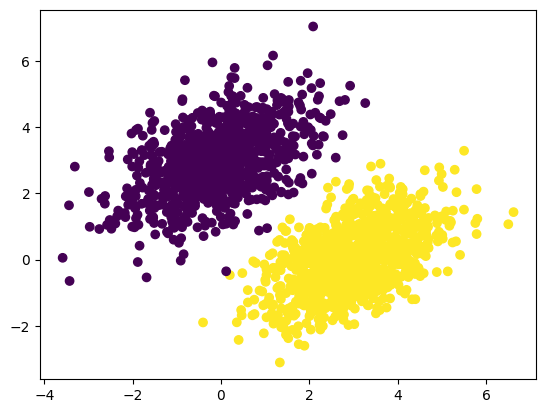

In [ ]:
plt.scatter(inputs[:,0], inputs[:,1], c =predictions[:, 0] > 0.5)
plt.show()

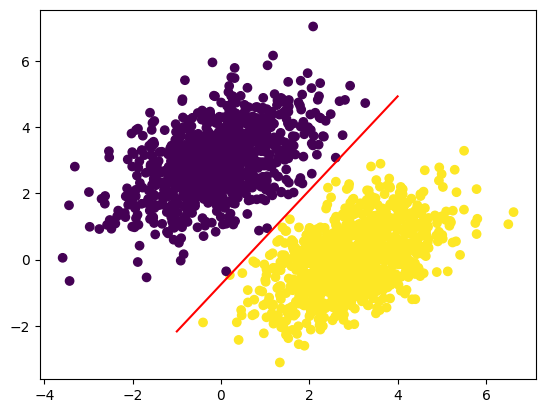

In [ ]:
x = np.linspace(-1,4,100)
y = -W[0] / W[1] * x + (0.5 - b) / W[1]
plt.plot(x,y, "-r")
plt.scatter(inputs[:,0], inputs[:,1], c =predictions[:, 0] > 0.5)

In [ ]:
W.shape

TensorShape([2, 1])

In [ ]:
W[0]

<tf.Tensor: shape=(1,), dtype=float32, numpy=array([0.17414133], dtype=float32)>

In [ ]:
W[1]

<tf.Tensor: shape=(1,), dtype=float32, numpy=array([-0.12245187], dtype=float32)>

In [ ]:
print(W)

<tf.Variable 'Variable:0' shape=(2, 1) dtype=float32, numpy=
array([[ 0.17414133],
       [-0.12245187]], dtype=float32)>


In [ ]:
print(b)

<tf.Variable 'Variable:0' shape=(1,) dtype=float32, numpy=array([0.40804616], dtype=float32)>


# A Dense Layer implemented as a Layer subclass

In [ ]:
from tensorflow import keras

In [ ]:
class SimpleDense(keras.layers.Layer):

  def __init__(self, units, activation):
    super().__init__()
    self.units = units
    self.activation = activation

  def build(self, input_shape):
    input_dim = input_shape[-1]
    self.W = self.add_weight(shape=(input_dim, self.units),
                             initializer ="random_normal")
    self.b = self.add_weight(shape=(self.units, ),
                             initializer = "zeros")

  def call(self, inputs):
    y = tf.matmul(inputs,self.W) + self.b
    if self.activation is not None:
      y = self.activation(y)
    return y


In [ ]:
my_dense = SimpleDense(units=32, activation=tf.nn.relu)
input_tensor = tf.ones(shape=(2, 784))
output_tensor = my_dense(input_tensor)
print(output_tensor.shape)

(2, 32)


In [ ]:
input_tensor.shape

TensorShape([2, 784])

In [ ]:
input_tensor.shape[-1]

784

In [ ]:
from tensorflow.keras import models
from tensorflow.keras import layers



In [ ]:
model = keras.Sequential([keras.layers.Dense(1)])
model.compile(optimizer=keras.optimizers.RMSprop(learning_rate=0.1),
              loss=keras.losses.MeanSquaredError(),
              metrics=[keras.metrics.BinaryAccuracy()])

indices_permutation = np.random.permutation(len(inputs))
shuffled_inputs= inputs[indices_permutation]
shuffled_targets = targets[indices_permutation]

num_validation_samples = int(0.3 * len(inputs))
val_inputs = shuffled_inputs[:num_validation_samples]
val_targets = shuffled_targets[:num_validation_samples]
training_inputs = shuffled_inputs[num_validation_samples:]
training_targets = shuffled_targets[num_validation_samples:]

model.fit(
    training_inputs,
    training_targets,
    epochs=5,
    batch_size=16,
    validation_data=(val_inputs, val_targets)
)

Epoch 1/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - binary_accuracy: 0.9650 - loss: 0.1585 - val_binary_accuracy: 0.9933 - val_loss: 0.0379
Epoch 2/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - binary_accuracy: 0.9621 - loss: 0.0687 - val_binary_accuracy: 0.9950 - val_loss: 0.0590
Epoch 3/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - binary_accuracy: 0.9679 - loss: 0.0670 - val_binary_accuracy: 0.9433 - val_loss: 0.0724
Epoch 4/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - binary_accuracy: 0.9664 - loss: 0.0692 - val_binary_accuracy: 0.9983 - val_loss: 0.0431
Epoch 5/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.9543 - loss: 0.0704 - val_binary_accuracy: 0.9000 - val_loss: 0.1386


In [ ]:
loss_and_metrics = model.evaluate(val_inputs, val_targets, batch_size=128)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - binary_accuracy: 0.9000 - loss: 0.1386 


In [ ]:
len(training_inputs)

1400

In [ ]:
len(val_inputs)

600

In [ ]:
val_inputs.shape

(600, 2)

In [ ]:
print(loss_and_metrics)

[0.13857926428318024, 0.8999999761581421]


In [ ]:
new_inputs.shape

NameError: name 'new_inputs' is not defined

In [ ]:
predictions = model.predict(val_inputs, batch_size=128)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


In [ ]:
print(predictions[:10])

[[ 0.1461367 ]
 [ 1.3533167 ]
 [ 0.43828213]
 [ 1.2448483 ]
 [ 1.5999746 ]
 [ 1.1453199 ]
 [-0.1341303 ]
 [ 1.5791565 ]
 [ 1.3769131 ]
 [ 1.5645403 ]]
